In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
train = pd.read_csv('/home/sagarikaborah/Documents/Mtech PES/Sem 2/DL and RL/s2/financial-risk-prediction/Train.csv')
test = pd.read_csv('/home/sagarikaborah/Documents/Mtech PES/Sem 2/DL and RL/s2/financial-risk-prediction/Test.csv')

In [4]:
print(train.shape)
train.head()

(543, 8)


,City,Location_Score,Internal_Audit_Score,External_Audit_Score,Fin_Score,Loss_score,Past_Results,IsUnderRisk
0,2,8.032,14,8,3,6,0,1
1,31,77.730,8,3,3,8,1,0
2,40,59.203,3,12,11,3,0,1
3,12,73.080,4,5,7,6,0,0
4,4,15.666,13,15,6,7,2,1


In [5]:
print(test.shape)
test.head()

(233, 7)


,City,Location_Score,Internal_Audit_Score,External_Audit_Score,Fin_Score,Loss_score,Past_Results
0,41,18.272,13,12,9,7,0
1,17,64.799,6,10,7,4,1
2,31,68.890,3,3,7,8,0
3,3,16.492,15,10,7,4,1
4,9,17.178,7,3,8,3,1


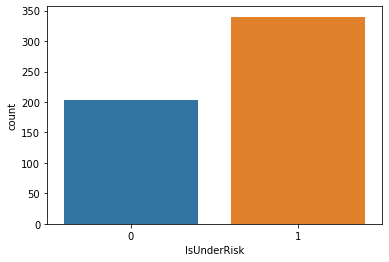

In [6]:
sns.countplot(train['IsUnderRisk'])
plt.show()

In [7]:
train.describe()

,City,Location_Score,Internal_Audit_Score,External_Audit_Score,Fin_Score,Loss_score,Past_Results,IsUnderRisk
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,19.576427,32.259346,8.189687,7.327808,7.046041,5.530387,0.613260,0.626151
std,14.722687,24.887291,3.312022,3.450667,3.156978,1.839124,0.764509,0.484270
min,0.000000,5.185000,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000
25%,6.000000,13.565000,6.000000,5.000000,5.000000,4.000000,0.000000,0.000000
50%,14.000000,19.803000,8.000000,7.000000,7.000000,6.000000,1.000000,1.000000
75%,37.000000,62.594000,11.000000,10.000000,8.000000,7.000000,1.000000,1.000000
max,44.000000,80.809000,15.000000,15.000000,15.000000,13.000000,10.000000,1.000000


In [8]:
train['Location_Score'] = np.log(train['Location_Score'])

In [9]:
train.describe()

,City,Location_Score,Internal_Audit_Score,External_Audit_Score,Fin_Score,Loss_score,Past_Results,IsUnderRisk
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,19.576427,3.172367,8.189687,7.327808,7.046041,5.530387,0.613260,0.626151
std,14.722687,0.780196,3.312022,3.450667,3.156978,1.839124,0.764509,0.484270
min,0.000000,1.645770,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000
25%,6.000000,2.607493,6.000000,5.000000,5.000000,4.000000,0.000000,0.000000
50%,14.000000,2.985833,8.000000,7.000000,7.000000,6.000000,1.000000,1.000000
75%,37.000000,4.136669,11.000000,10.000000,8.000000,7.000000,1.000000,1.000000
max,44.000000,4.392088,15.000000,15.000000,15.000000,13.000000,10.000000,1.000000


In [10]:
var_with_na = [var for var in train.columns if train[var].isnull().sum()>1]

for var in var_with_na:
    print(train, var)

In [11]:
X = train.iloc[:, train.columns != 'IsUnderRisk']
y = train.iloc[:, train.columns == 'IsUnderRisk']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.20, random_state=0)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [15]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

In [16]:
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)



/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """Entry point for launching an IPython kernel.


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [19]:
print(cm)

[[39  6]
 [10 54]]


In [20]:
print(cr)

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        45
           1       0.90      0.84      0.87        64

    accuracy                           0.85       109
   macro avg       0.85      0.86      0.85       109
weighted avg       0.86      0.85      0.85       109



In [21]:
from keras.models import Sequential 
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import EarlyStopping

In [22]:
model = Sequential()
model.add(Dense(30,activation='relu'))
model.add(Dense(15,activation='relu'))
model.add(Dense(2,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam')

In [23]:
model.fit(x=X_train,y=y_train.values,epochs=2, validation_data=(X_test,y_test.values), verbose=1)

Epoch 1/2
14/14 [==============================] - 0s 13ms/step - loss: 0.7085 - val_loss: 0.6449
Epoch 2/2
14/14 [==============================] - 0s 3ms/step - loss: 0.6191 - val_loss: 0.6001


In [24]:
model_loss = pd.DataFrame(model.history.history)

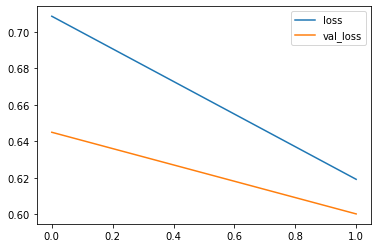

In [25]:
model_loss.plot()

In [26]:
model = Sequential()
model.add(Dense(30,activation='relu'))
model.add(Dense(15,activation='relu'))
model.add(Dense(2,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam')

In [27]:
early_stop = EarlyStopping(monitor='val_loss', mode='max', verbose=1, patience=25)

In [28]:
model.fit(x=X_train,y=y_train.values,epochs=600,validation_data=(X_test, y_test.values), verbose=1,callbacks=[early_stop])

Epoch 1/600
14/14 [==============================] - 0s 11ms/step - loss: 0.7402 - val_loss: 0.7039
Epoch 2/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6921 - val_loss: 0.6730
Epoch 3/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6532 - val_loss: 0.6418
Epoch 4/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6181 - val_loss: 0.6115
Epoch 5/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5828 - val_loss: 0.5759
Epoch 6/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5470 - val_loss: 0.5366
Epoch 7/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5114 - val_loss: 0.4968
Epoch 8/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4773 - val_loss: 0.4563
Epoch 9/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4474 - val_loss: 0.4267
Epoch 10/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4244 - val_loss: 0.4064
Epoch 11

In [29]:
model_loss = pd.DataFrame(model.history.history)

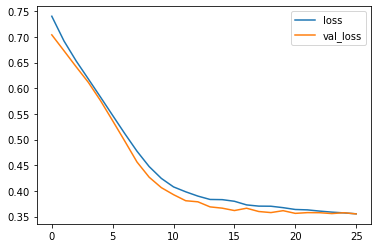

In [30]:
model_loss.plot()

In [31]:
from sklearn.metrics import classification_report,confusion_matrix

In [32]:
predictions = model.predict_classes(X_test)

In [33]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79        45
           1       0.86      0.84      0.85        64

    accuracy                           0.83       109
   macro avg       0.82      0.82      0.82       109
weighted avg       0.83      0.83      0.83       109



In [34]:
print(confusion_matrix(y_test, predictions))

[[36  9]
 [10 54]]


In [35]:
predictions = model.predict_classes(test)

In [36]:
submission = pd.DataFrame(data=predictions)
submission.head()
submission.to_csv('Predictions.csv')